<a href="https://colab.research.google.com/github/adamtmoser/July26_BCCE/blob/main/Worked_Version_of_003_AI_coding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img align="right" src="https://github.com/codeBMB/April26_Rutgers-RCSB/raw/main/images/PyBMB_logo.png" width="150" height="150" />

# Project: CodeBMB: Computational Literacy for Biochemistry and Molecular Biology Education
## Notebook: Introduction to AI and coding

**Purpose:**
Coding in Python can be challenging when you get an error code that is indecipherable or don't know quite how to make the plot look right. This is where Large Language Models (sometimes called AI) can assist. Incorporated directly into Google Colab is Gemini, Google's LLM which has a reasonable track record for developing functional code. In Colab, Gemini can directly diagnose errors and patch the code or it can provide code based on prompts in your code blocks. We will explore both along with best practices for troubleshooting and code development.

*While we will use Gemini for simplicity, any cloud-based LLM (i.e. Claude or ChatGPT) can help develop and troubleshoot code and there are methods to install LLMs locally to use other algorithms which are code focused. Whichever path you take, these lessons can be applied.*


**By the end of this notebook you will be able to:**
- Develop Python code to carry out calculations and visualizations
- Turn on AI assistance in Google Colab
- Read error messages in Colab and ask Gemini to help repair the error
- Develop code using the Gemini prompts
- Write LLM prompts for code development
- Learn how to develop entire notebooks with LLM assistance

**Libraries:**
* `pandas` — loading and organizing data in tables (DataFrames)
* `numpy` - for working with numerical data
* `matplotlib` — creating plots and graphs
* `seaborn` - create fancier plots
* `scipy` - fitting data

**Status:** BCCE 2026 Workshop — July 2026

**License**

<img src="https://github.com/codeBMB/April26_Rutgers-RCSB/raw/main/images/by-nc-sa.png" width="100"/>
CC BY-NC-SA — free to use and adapt for non-commercial educational purposes with attribution.

---
**Author:** Chris Berndsen

**Acknowledgements:** Supported by NSF IUSE 2518732 and 2518733.

**Contact:** codingforBMB [at] gmail [dot] com

## Turning on AI assistance in Google Colabs

By default, AI assistance is active in Google Colabs and you may want to turn it off or on for different experiences for you and your students.

To activate AI assistance in Colab:
1. Go to `Tools` then `Settings`
2. In the `Settings` menu, go to `AI Assistance`
3. For AI full capabilities the boxes should be marked as in the image below:

![AI image options](https://github.com/codeBMB/July26_BCCE/raw/main/images/AI_options_colab.png)

If you want to deactivate the AI capabilities, reverse the box settings.

**NOTE:** As with all LLM based in the cloud, Gemini can make mistakes and your data and conversations ARE NOT private.


---

## Accessing Gemini features and assistance in Colab

Gemini can be accessed a few different ways:
1. The "sparkle" button at the bottom center of the Chrome window. This opens a side window where you can start a conversation

2. In a code block, the "sparkle pen" icon (usually next to the trash can icon). Pressing this button gives three options depending on the code block.

    - **Generate code** if the block is empty and you want to write code
    - **Explain code** if there is code present that you want Gemini to talk you through.
    - **Transform code** if there is code present, which you want to further develop or adapt.


3. Inline code assistance. A passive integration of Gemini akin to autocorrect or autotext which completes code.

4. The `Explain Error` button that appears after a code error. This brings up the sidebar to troubleshoot the error.

3. In the menu bar in the `+ Code` menu is add an AI prompt code block.  This creates a special code block in the notebook that allows for LLM chatting within the notebook.

---

We will play with all five ways of using Gemini, starting with the inline assistance and error generation as these are the most straightforward to use. At the end of this activity, we will explore code and notebook generation.


## Inline code assistance
The inline assistance is often the first interaction with Gemini in Colab. To get inline assistance, write a comment in the code with your goal, then move to the next line and start the code. Gemini will suggest how to complete your code, which you can press the Tab key to accept.

Example:

```
1 # Import a csv file from Github using pandas
2 df = pd.read_csv('https://raw.githubusercontent.com/plotly/datasets/master/gapminder2007.csv')
3 df.head()
```
Line 1 is the comment in the code (like a prompt). I typed `df =` on Line 2 and the completed code on lines 2 and 3 were the suggested code from Gemini with an example data link in the `pd.read_csv()` call.

Try the inline assistance below using the existing prompt. After the comment, press return to start a new line, then type `import` and Gemini should complete the appropriate code.


In [1]:
# Block 1, inline code assistance example
# import pandas, matplotlib, seaborn, and scipy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp

Now write a comment and code to import the red40 standard curve data from the link address below.  Remember to indicate the file format (.csv) and library to use (pandas) in your comment.

**Link to use:** https://github.com/codeBMB/July26_BCCE/raw/main/data/red40_std_curve.csv

In [12]:
# import a csv file from https://github.com/codeBMB/July26_BCCE/raw/main/data/red40_std_curve.csv
# import the file for use in pandas
df = pd.read_csv('https://github.com/codeBMB/July26_BCCE/raw/main/data/red40_std_curve.csv')
# write out the df for inspection
display(df.head())
# calculate the average of column 2 titled Rep1 and print this below the head output above
print(df['Rep1'].mean())

,Concentration_uM,Rep1,Rep2,Rep3
0,0,0.001,0.002,0.000
1,5,0.129,0.128,0.127
2,10,0.264,0.262,0.251
3,20,0.537,0.513,0.522
4,40,1.031,1.027,1.013


0.807


### A few caveats to inline text assistance


1.   Comments may not provide enough context for auto-complete to be accurate.
2.   Example links or names may be added that you need to alter (see example with GitHub link above)
3.   Extra code might be added (like the `df.head()` on line 3 above)
4.   Gemini provided code is like autocorrect, it is the most probable based on the comment, but may not your goal. Be skeptical!

---



## Troubleshooting with Gemini
Code breaks or fails and sometimes the error code is challenging to understand. When a code block fails, an `Explain Error` button will appear that will work through the error and offer a suggested fix. The code in the block below should fail (it was written incorrectly) so that you can see a Python error message and then use Gemini to help. Additionally, we will give some tips on reading Python error messages to help refine the error message prompt to Gemini and improve the accuracy of the fix.

---

The code below creates two arrays of numbers in numpy and then attempts to assemble them into two columns of a pandas dataframe. There are a few errors to troubleshoot so anticipate several rounds of Gemini assistance. You may even see and know how to fix the problems (good job!)

In [ ]:
# create the two arrays
x_arr = np.array[1,1,2,3,5,8,11]
y_arr = numpy.array[2,2,3,4,6,9,12]

# assemble them into a dataframe in columns called left and right
df = pd.DataFrame({left: x_arr,
                   'right': y_arr})

# view the dataframe
df.head

The code above contains at least 3 errors:
1. np versus numpy to call numpy library
2. left in the pd.DataFrame call is not in quotes
3. df.head is missing parenthesis

---

When the error occurs, the output will like similar to this:

![python error code identifying the numpy naming error](https://github.com/codeBMB/July26_BCCE/raw/main/images/python_error.png)

There are a few things to note about the error message:
1. The error indicates **where** in the code the problem occurred, in this example it is in line 2.
2.  The type of error is indicated, in this case a `NameError`, meaning Python does not recognize something named with np.

Below the error message is the `Explain Error` button. Press it and Gemini will attempt to fix the error and then respond. An example response for the code block:

![Gemini response to error](https://github.com/codeBMB/July26_BCCE/raw/main/images/ai_response.png)

Note that Gemini identified all the errors in the code and altered the code block to show original code in red lines and the changes or fixes in the green lines. Then it allows you to fix the code or provide more information by pressing one of the buttons below:

![Gemini buttons in colab](https://github.com/codeBMB/July26_BCCE/raw/main/images/buttons.png)

Pressing `Accept and Run` results in the green code lines being accepted as correct and running the block to see if it works. `Accept` means the changes are fine but you don't want to run the block. `Cancel` means you don't want Gemini to replace the code and it deletes the suggested fixes.

If the code fails with the Gemini suggested fixes, Gemini will troubleshoot the next error or provide additional suggestions.



### Caveats to Gemini `Explain Error`
1. Explain error only troubleshoots the code in the block that causes the error. If there are missing imports or silent errors from earlier blocks, it may not see this issue.
2. If the error is complex or in a less common library, Gemini may not diagnose the error correctly or find a solution.
3. Gemini can create upstream and downstream errors by changing names or file types.

---




## Developing code with Gemini

We've already written a bit of code using Gemini in the Inline AI assistance example where we had Gemini populate a line or two of code based on a prompt. We can use Gemini to generate code blocks without the commenting and even entire notebooks. These activities require longer prompts and specificity. Additionally, generating larger code or notebooks off a single prompt can present challenges and you will likely need the inline assistance and explain error to fix problems during testing.

---

### Best practices for prompting
A good prompt to start building a coding assignment needs to include enough context for the LLM to produce a result that can be refined. Simply asking for code that can produce an outcome leaves too many gaps in the context for the LLM to build. Some LLMs will ask for more information, while others will just build leaving you to do more testing and refinement.

**Information to include in a good prompt:**

1)	Language
2)	Packages to use
3)	What level of student
4)	Input data format
5)	Input data file type
6)	Libraries to use
7)	Which equation to use to fit
8)	Clear description of the output and goals
9)	Other requirements or goals

---

In the empty block below, use the sparkle pen icon to access Gemini and provide the following prompt:

**Write code to import the linked notebook and make the data into a single column**

https://github.com/codeBMB/July26_BCCE/blob/main/data/red40_std_curve.csv

In [13]:
import pandas as pd

# URL to the CSV file
url = 'https://github.com/codeBMB/July26_BCCE/raw/main/data/red40_std_curve.csv'

# Read the CSV into a pandas DataFrame
df_raw = pd.read_csv(url)

# Melt the DataFrame to combine 'Rep1', 'Rep2', 'Rep3' into a single column
df_single_column = pd.melt(df_raw, id_vars=['Concentration_uM'],
                          value_vars=['Rep1', 'Rep2', 'Rep3'],
                          var_name='Replicate', value_name='Measurement')

# Display the head of the new DataFrame
df_single_column.head()

,Concentration_uM,Replicate,Measurement
0,0,Rep1,0.001
1,5,Rep1,0.129
2,10,Rep1,0.264
3,20,Rep1,0.537
4,40,Rep1,1.031


Now, try the activity in the code block again below but indicate you can to combine the replicates into a single column so you end up with a concentration column and a measurement column.



In [14]:
# Display the raw DataFrame before melting
display(df_raw.head())

,Concentration_uM,Rep1,Rep2,Rep3
0,0,0.001,0.002,0.000
1,5,0.129,0.128,0.127
2,10,0.264,0.262,0.251
3,20,0.537,0.513,0.522
4,40,1.031,1.027,1.013


Now have Gemini explain the code to understand what the output means.

If Gemini included a `replicate` column in the output file, ask Gemini to remove this column and regenerate the code.

Also notice that Gemini gives suggested prompts or activities building on the file import that you can do.

---




### Gemini sidebar
Now let's create plot using the in notebook Gemini block. In this block, ask Gemini to create a plot of the data you just imported. You can find the dataframe title in the code or ask Gemini to help find it. Provide as much specificity as you can to help generate the code in one prompt.

Open a code block, press the sparkle pen icon, and generate the code using the sidebar Gemini. Try to get the prompt to generate a mostly final plot on the first try. Remember to ask Gemini to explain the code in the end.

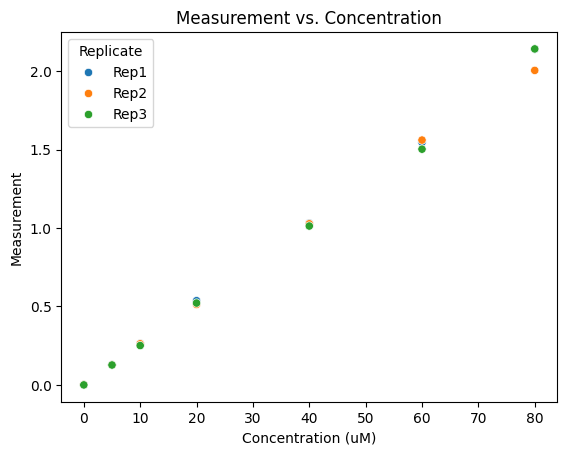

In [15]:
# Create a scatter plot
sns.scatterplot(data=df_single_column, x='Concentration_uM', y='Measurement', hue='Replicate')

# Add labels and title
plt.xlabel('Concentration (uM)')
plt.ylabel('Measurement')
plt.title('Measurement vs. Concentration')

# Display the plot
plt.show()

In [18]:
df_averaged = df_single_column.groupby('Concentration_uM')['Measurement'].mean().reset_index()
display(df_averaged)

,Concentration_uM,Measurement
0,0,0.001000
1,5,0.128000
2,10,0.259000
3,20,0.524000
4,40,1.023667
5,60,1.536667
6,80,2.096000


In [19]:
df_std = df_single_column.groupby('Concentration_uM')['Measurement'].std().reset_index()
df_averaged['Measurement_std'] = df_std['Measurement']
display(df_averaged.head())

,Concentration_uM,Measurement,Measurement_std
0,0,0.001000,0.001000
1,5,0.128000,0.001000
2,10,0.259000,0.007000
3,20,0.524000,0.012124
4,40,1.023667,0.009452


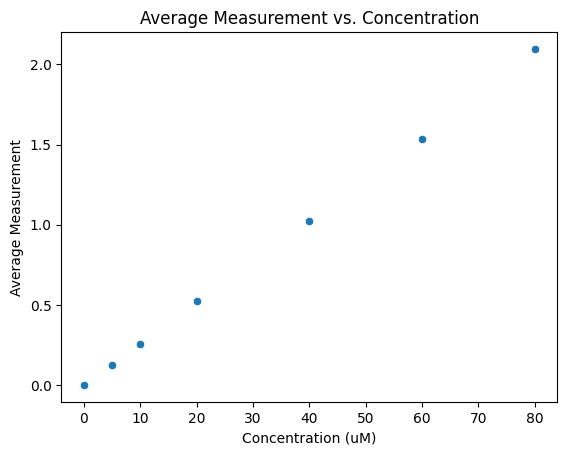

In [17]:
# Create a scatter plot of averaged data
sns.scatterplot(data=df_averaged, x='Concentration_uM', y='Measurement')

# Add labels and title
plt.xlabel('Concentration (uM)')
plt.ylabel('Average Measurement')
plt.title('Average Measurement vs. Concentration')

# Display the plot
plt.show()

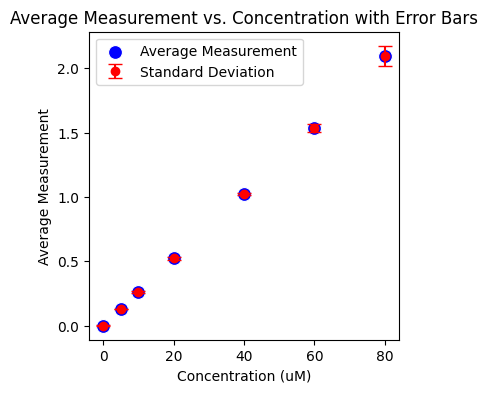

In [21]:
# Create a scatter plot of averaged data with error bars
plt.figure(figsize=(4, 4))
sns.scatterplot(data=df_averaged, x='Concentration_uM', y='Measurement', s=100, color='blue', label='Average Measurement')
plt.errorbar(x=df_averaged['Concentration_uM'], y=df_averaged['Measurement'], yerr=df_averaged['Measurement_std'], fmt='o', color='red', capsize=5, label='Standard Deviation')

# Add labels and title
plt.xlabel('Concentration (uM)')
plt.ylabel('Average Measurement')
plt.title('Average Measurement vs. Concentration with Error Bars')
plt.legend()

# Display the plot
plt.show()

The `+ Code > AI Prompt Cell` allows you run an AI interface in your notebook akin to running ChatGPT or Claude in the web browser. Unlike the other Gemini options, you can:
* Pick your Gemini model
* Keep your notebook separate from Gemini as it can be included when AI assistance is turned off
* Ask non-code questions

However, you cannot
* have it generate code blocks
* have it read your notebook directly

This option for AI may be better for data and notebook security but it is limited as a code assistant.  Try it below after having tried the other methods to access Gemini within this notebook.


In [ ]:
# @title AI prompt cell

import ipywidgets as widgets
from IPython.display import display, HTML, Markdown,clear_output
from google.colab import ai

dropdown = widgets.Dropdown(
    options=[],
    layout={'width': 'auto'}
)

def update_model_list(new_options):
    dropdown.options = new_options
update_model_list(ai.list_models())

text_input = widgets.Textarea(
    placeholder='Ask me anything....',
    layout={'width': 'auto', 'height': '100px'},
)

button = widgets.Button(
    description='Submit Text',
    disabled=False,
    tooltip='Click to submit the text',
    icon='check'
)

output_area = widgets.Output(
     layout={'width': 'auto', 'max_height': '300px','overflow_y': 'scroll'}
)

def on_button_clicked(b):
    with output_area:
        output_area.clear_output(wait=False)
        accumulated_content = ""
        for new_chunk in ai.generate_text(prompt=text_input.value, model_name=dropdown.value, stream=True):
            if new_chunk is None:
                continue
            accumulated_content += new_chunk
            clear_output(wait=True)
            display(Markdown(accumulated_content))

button.on_click(on_button_clicked)
vbox = widgets.GridBox([dropdown, text_input, button, output_area])

display(HTML("""
<style>
.widget-dropdown select {
    font-size: 18px;
    font-family: "Arial", sans-serif;
}
.widget-textarea textarea {
    font-size: 18px;
    font-family: "Arial", sans-serif;
}
</style>
"""))
display(vbox)


In [ ]:
#Paste the code from the AI prompt cell here

### Caveats to using Gemini to develop the code blocks and notebooks
1. *Specificity matters*! You need to know what the output should be or have a good outline of your steps to guide the LLM
2. Using Gemini sparkle or the AI code block to generate the code produces outputs in different ways. The sparkle is integrated into the notebook, while the prompt produces code like a cloud-based AI.
3.  You may get different code from the same prompt during different sessions.





## Tips for generating notebooks with AI
1.  Write an outline or a template to help Gemini know your plan. [PyBMB Colab template for general notebooks](https://github.com/codeBMB/July26_BCCE/raw/main/PyBMB_Notebook_Template_Gemini.ipynb)
2.  Work outside of Colab first. Generate the code using a cloud-based or local LLM and ask it to brainstorm or discuss the code with you. This will teach you the vocabulary and may be easier to include mock data to help with code generation. Then, copy the code into Colab and troubleshoot using internal Gemini.
3.  Write in small chunks and iterate rather than one big block at once.
4.  Know the libraries, the file format, general plan for processing, etc.
5. Garbage in, garbage out! The better your plan is, the better your prompt will be, and the better your final product.